# Read Cloud Results

Load fetched cloud result files and recreate the plots from `main_HF.ipynb`. Set `shots`, `MOLECULE`, and `BOND_LENGTH` in the first code cell to choose a run such as `data/shots_8192/HF_bond_1.2` or `data/shots_81920/HF_bond_2.2`. The notebook plots VQE convergence/error from `vqe_results.json` and shows CMX/CME only when non-empty sweep data is present.

In [1]:
from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 140})

# Choose which fetched cloud run to read.
DATA_ROOT = Path("data")
shots = 81920  # e.g. 8192 -> data/shots_8192, 81920 -> data/shots_81920
MOLECULE = "HF"
BOND_LENGTH = 2.2
SHOTS_DIR = DATA_ROOT / f"shots_{shots}"
RUN_DIR = SHOTS_DIR / f"{MOLECULE}_bond_{BOND_LENGTH:.1f}"

shot_dirs = sorted(p for p in DATA_ROOT.glob("shots_*") if p.is_dir())
print("Available shot budgets:")
for i, shot_dir in enumerate(shot_dirs):
    print(f"{i}: {shot_dir}")

if not SHOTS_DIR.is_dir():
    available = ", ".join(str(p) for p in shot_dirs) or "none"
    raise FileNotFoundError(
        f"Shots directory not found: {SHOTS_DIR}. "
        f"Set shots to one of the available budgets: {available}"
    )

runs = sorted(p for p in SHOTS_DIR.glob("*_bond_*") if p.is_dir())
print(f"\nAvailable runs under {SHOTS_DIR}:")
for i, run in enumerate(runs):
    print(f"{i}: {run}")

if not RUN_DIR.is_dir():
    available = ", ".join(str(run) for run in runs) or "none"
    raise FileNotFoundError(
        f"Run directory not found: {RUN_DIR}. "
        f"Set MOLECULE/BOND_LENGTH to one of the available runs: {available}"
    )

print(f"\nSelected run: {RUN_DIR}")
RUN_DIR


Available shot budgets:
0: data/shots_8192
1: data/shots_81920

Available runs under data/shots_81920:
0: data/shots_81920/HF_bond_1.2
1: data/shots_81920/HF_bond_2.2

Selected run: data/shots_81920/HF_bond_2.2


PosixPath('data/shots_81920/HF_bond_2.2')

In [2]:
EXPECTED_FILES = (
    "run_summary.json",
    "vqe_results.json",
    "vqe_results.pkl",
    "cme_results.json",
    "cme_results_by_multiplier.json",
    "all_results.pkl",
)


def load_json(name):
    path = RUN_DIR / name
    if not path.exists() or path.stat().st_size == 0:
        return None
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        print(f"Warning: {path.name} exists but is not valid JSON; ignoring.")
        return None


def load_pickle(name):
    path = RUN_DIR / name
    if not path.exists() or path.stat().st_size == 0:
        return None
    with path.open("rb") as handle:
        return pickle.load(handle)


def as_float_array(records, key):
    return np.asarray([float(row[key]) for row in records], dtype=float)


def inventory_run_dir():
    print("Run file inventory:")
    for name in EXPECTED_FILES:
        path = RUN_DIR / name
        if not path.exists():
            status = "missing"
        elif path.stat().st_size == 0:
            status = "empty"
        else:
            status = f"ok ({path.stat().st_size:,} B)"
        print(f"  {name:<32} {status}")


inventory_run_dir()

summary = load_json("run_summary.json") or {}
vqe_results = load_json("vqe_results.json")
if vqe_results is None:
    vqe_results = load_pickle("vqe_results.pkl")
    if vqe_results is not None:
        print("Loaded VQE results from vqe_results.pkl (JSON missing or empty).")

cme_results = load_json("cme_results.json")
if cme_results is None:
    cme_results = load_pickle("cme_results.pkl")

cme_by_multiplier = load_json("cme_results_by_multiplier.json") or {}
if not cme_by_multiplier:
    cme_by_multiplier = load_pickle("cme_results_by_multiplier.pkl") or {}

molecule = summary.get("molecule", RUN_DIR.name.split("_bond_")[0])
bond_length = float(summary.get("bond_length", RUN_DIR.name.split("_bond_")[-1]))

# Exact ground-state references (Hartree) from Pauli_Ham bond scans / saved CMX runs.
KNOWN_GS_ENERGIES = {
    ("HF", 1.2): -98.57387833667892,
    ("HF", 2.2): -98.45842350054684,
    ("Cl2", 2.2): -909.143531683094,
}

e_ref = None
if cme_by_multiplier:
    first_cme = next(iter(cme_by_multiplier.values()))
    e_ref = first_cme.get("e_gs")
if e_ref is None:
    e_ref = KNOWN_GS_ENERGIES.get((molecule, round(bond_length, 1)))
if e_ref is None:
    print(
        "Warning: no ground-state reference for this run. "
        "VQE error plots will be skipped; add an entry to KNOWN_GS_ENERGIES."
    )
else:
    e_ref = float(e_ref)

print(json.dumps(summary, indent=2))
if e_ref is not None:
    print(f"Ground-state reference: {e_ref:.12f} Eh")
print(f"Has VQE curves: {vqe_results is not None}")
print(f"Has CMX sweep: {bool(cme_by_multiplier)}")


Run file inventory:
  run_summary.json                 ok (385 B)
  vqe_results.json                 ok (13,757 B)
  vqe_results.pkl                  ok (5,625 B)
  cme_results.json                 ok (1,216 B)
  cme_results_by_multiplier.json   ok (3,965 B)
  all_results.pkl                  ok (7,692 B)
{
  "bond_length": 2.2,
  "created_utc": "2026-07-10T22:21:42.591393+00:00",
  "has_cme_results": true,
  "has_cme_results_by_multiplier": true,
  "has_vqe_results": true,
  "metadata": {
    "cdr_training_circuits": 30,
    "circuit_name": "HF_8q_3doubles_rzx",
    "measurement_scheme": "ogm",
    "num_shots": 81920,
    "vqe_iters": 15
  },
  "molecule": "HF",
  "stage": "final"
}
Ground-state reference: -98.458423500547 Eh
Has VQE curves: True
Has CMX sweep: True


Using true GS reference energy: -98.458423500547 Eh
Best REM+CF energy: -98.493307133402 Eh
Best REM+CF error: 3.488363e-02 Eh

REM+CF energy by iteration:
  iter         REM+CF (Eh)   |E - E_GS| (Eh)
     0    -98.228274127693      2.301494e-01
     1    -98.272683678877      1.857398e-01
     2    -98.308840876859      1.495826e-01
     3    -98.304024550308      1.543990e-01
     4    -98.371876168894      8.654733e-02
     5    -98.374500624695      8.392288e-02
     6    -98.410870712444      4.755279e-02
     7    -98.472129071330      1.370557e-02
     8    -98.430449762840      2.797374e-02
     9    -98.409614011068      4.880949e-02
    10    -98.385912499256      7.251100e-02
    11    -98.440089100835      1.833440e-02
    12    -98.457064316745      1.359184e-03
    13    -98.493307133402      3.488363e-02
    14    -98.477194429150      1.877093e-02
    15    -98.424018252530      3.440525e-02


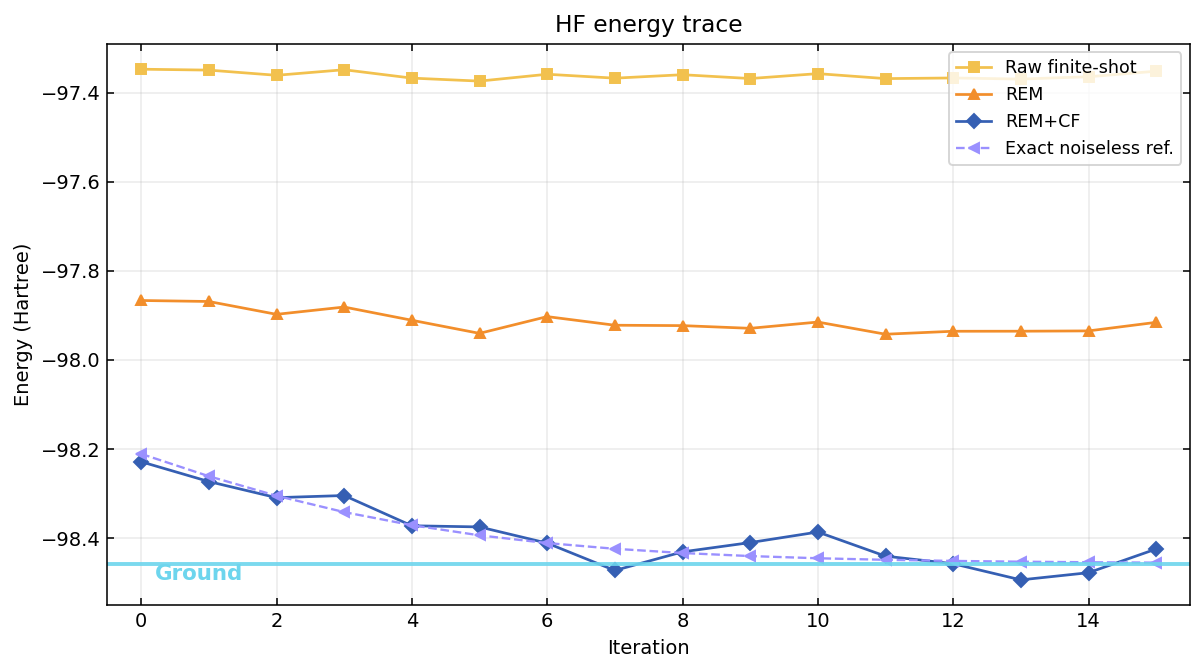

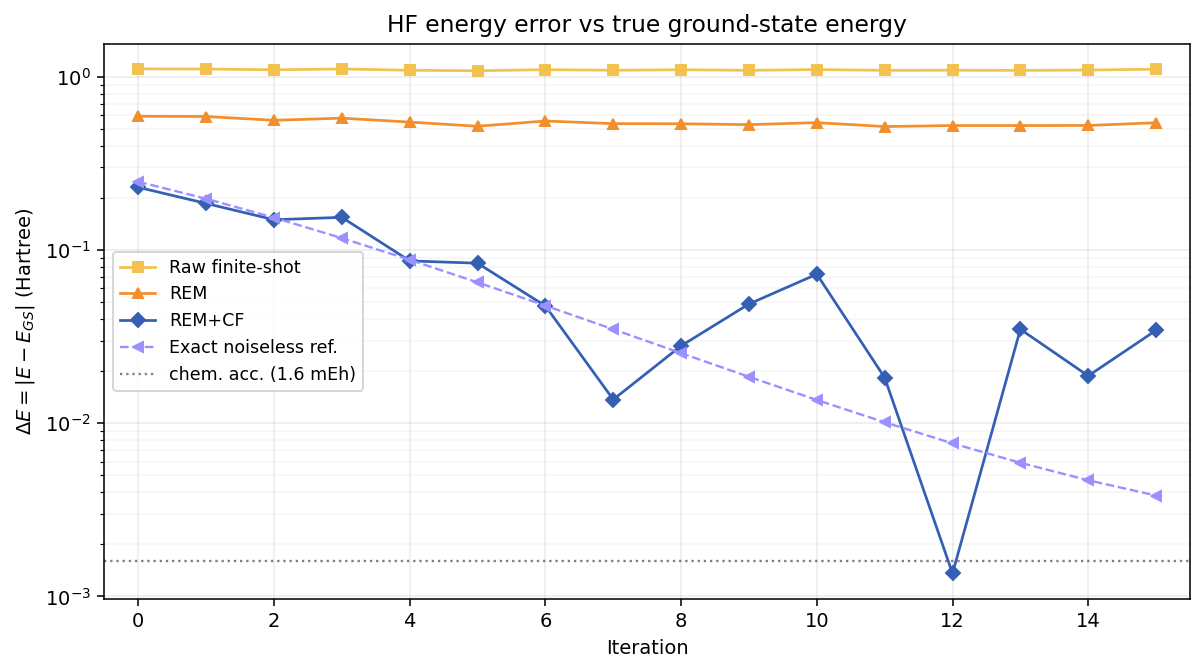

In [3]:
# --- VQE plots from saved cloud data: energy trace + log-scale error vs true GS ---
if vqe_results is None:
    print("No VQE results found in", RUN_DIR)
elif e_ref is None:
    print("Skipping VQE plots: ground-state reference unavailable for", RUN_DIR.name)
else:
    ec = vqe_results["energy_curves"]
    xs = as_float_array(ec, "iter")
    raw = as_float_array(ec, "raw_eh")
    rem = as_float_array(ec, "rem_eh")
    cf = as_float_array(ec, "rem_cf_eh")
    nls = as_float_array(ec, "noiseless_eh")

    style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
    style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
    style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
    style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless ref.")

    # ---- Energy trace ----
    fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
    ax1.plot(xs, raw, **style_raw)
    ax1.plot(xs, rem, **style_rem)
    ax1.plot(xs, cf, **style_cf)
    ax1.plot(xs, nls, **style_nls)
    ax1.axhline(e_ref, color="#6dd5ed", lw=2.0, alpha=0.9)
    ax1.text(xs.min() + 0.2, e_ref, "Ground", color="#6dd5ed", va="top", ha="left", fontsize=11, weight="bold")

    all_e = np.concatenate([raw, rem, cf, nls, [e_ref]])
    lo, hi = float(all_e.min()), float(all_e.max())
    pad = 0.05 * (hi - lo + 1e-9)
    ax1.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax1.set_ylim(lo - pad, hi + pad)
    ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Energy (Hartree)")
    ax1.set_title(f"{molecule} energy trace")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="best", fontsize=9)
    fig1.tight_layout()

    # ---- Absolute error vs true GS (log-y) ----
    floor = 1e-16
    err_raw = np.maximum(np.abs(raw - e_ref), floor)
    err_rem = np.maximum(np.abs(rem - e_ref), floor)
    err_cf = np.maximum(np.abs(cf - e_ref), floor)
    err_nls = np.maximum(np.abs(nls - e_ref), floor)

    fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
    ax2.plot(xs, err_raw, **style_raw)
    ax2.plot(xs, err_rem, **style_rem)
    ax2.plot(xs, err_cf, **style_cf)
    ax2.plot(xs, err_nls, **style_nls)
    ax2.set_yscale("log")
    ax2.axhline(1.6e-3, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")
    ax2.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
    ax2.set_title(f"{molecule} energy error vs true ground-state energy")
    ax2.grid(True, which="major", alpha=0.25)
    ax2.grid(True, which="minor", alpha=0.12)
    ax2.legend(loc="best", fontsize=9)
    fig2.tight_layout()

    print(f"Using true GS reference energy: {e_ref:.12f} Eh")
    print(f"Best REM+CF energy: {float(vqe_results['E_best']):.12f} Eh")
    print(f"Best REM+CF error: {abs(float(vqe_results['E_best']) - e_ref):.6e} Eh")
    print("\nREM+CF energy by iteration:")
    print(f"{'iter':>6}  {'REM+CF (Eh)':>18}  {'|E - E_GS| (Eh)':>16}")
    for i, e in zip(xs, cf):
        print(f"{int(i):6d}  {float(e):18.12f}  {abs(float(e) - e_ref):16.6e}")
    plt.show()


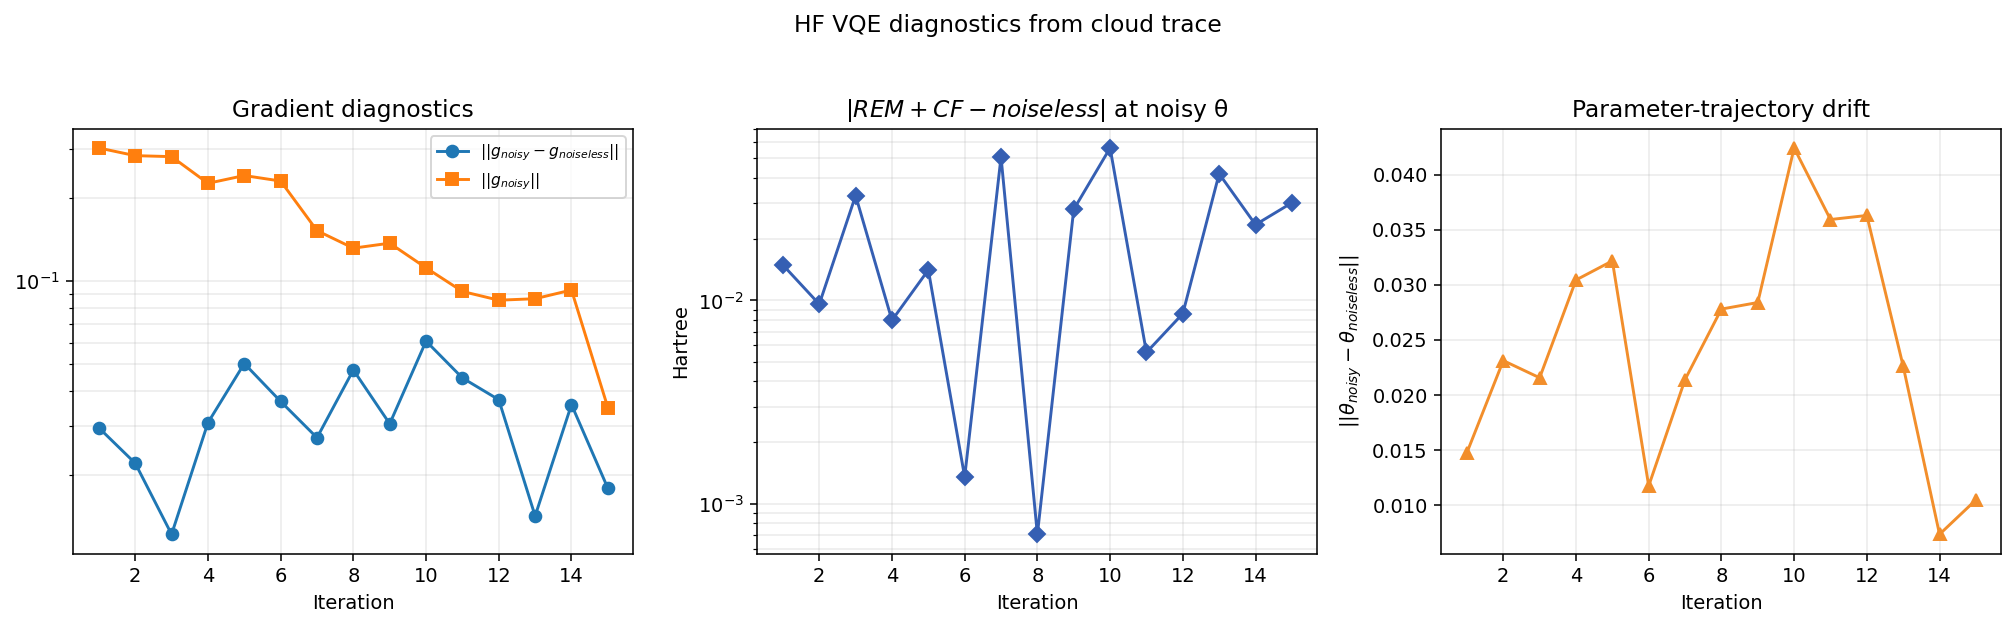

Measurement cost summary
  total CDR calls       : 107
  energy evals/call     : 31
  shots/eval            : 81920
  estimated total shots : 271,728,640
  calls by stage        : {'final': 1, 'init': 1, 'main_grad': 90, 'main_post': 15, 'noiseless_track': 32, 'total': 107, 'warmup': 0}


In [4]:
# --- Extra VQE diagnostics saved by the cloud run ---
if vqe_results is None or not vqe_results.get("trace"):
    print("No VQE trace diagnostics found in", RUN_DIR)
else:
    trace = vqe_results["trace"]
    it = as_float_array(trace, "iter")
    grad_diff = as_float_array(trace, "grad_diff")
    grad_norm = as_float_array(trace, "grad_noisy_norm")
    theta_diff = as_float_array(trace, "theta_diff")
    e_bias = as_float_array(trace, "e_bias")

    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

    axes[0].plot(it, grad_diff, marker="o", lw=1.5, label=r"$||g_{noisy}-g_{noiseless}||$")
    axes[0].plot(it, grad_norm, marker="s", lw=1.5, label=r"$||g_{noisy}||$")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Iteration")
    axes[0].set_title("Gradient diagnostics")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].plot(it, e_bias, marker="D", color="#355fb3", lw=1.5)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Hartree")
    axes[1].set_title(r"$|REM+CF - noiseless|$ at noisy θ")
    axes[1].grid(True, which="both", alpha=0.25)

    axes[2].plot(it, theta_diff, marker="^", color="#f28e2b", lw=1.5)
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel(r"$||\theta_{noisy}-\theta_{noiseless}||$")
    axes[2].set_title("Parameter-trajectory drift")
    axes[2].grid(True, alpha=0.25)

    fig.suptitle(f"{molecule} VQE diagnostics from cloud trace", y=1.03)
    fig.tight_layout()
    plt.show()

    cost = vqe_results.get("cost_model", {})
    counts = vqe_results.get("counts", {})
    if cost:
        print("Measurement cost summary")
        print(f"  total CDR calls       : {cost.get('total_cdr_calls', counts.get('total'))}")
        print(f"  energy evals/call     : {cost.get('energy_evals_per_cdr_call')}")
        print(f"  shots/eval            : {cost.get('num_shots_per_eval')}")
        print(f"  estimated total shots : {cost.get('total_shots_est'):,}")
        print(f"  calls by stage        : {counts}")


CMX/CME noiseless references and shot-budget results: HF_bond_2.2


,H2/H3 multiplier,H shots,H2 shots,H3 shots,<H> noiseless (Eh),<H2> noiseless (Eh^2),<H3> noiseless (Eh^3),E_cme noiseless (Eh),|noiseless CME - GS| (mEh),E_cme shots (Eh),E_gs (Eh),|shot CME - GS| (Eh),|shot CME - GS| (mEh),shot CME below chem. acc. (1.6 mEh)
0,5,409600,409600,409600,-98.451285,9692.660082,-954255.726019,-98.457622,0.801959,-99.186900,-98.458424,0.728476,728.476216,False
1,10,819200,819200,819200,-98.451285,9692.660082,-954255.726019,-98.457622,0.801959,-98.449588,-98.458424,0.008835,8.835224,False
2,20,1638400,1638400,1638400,-98.451285,9692.660082,-954255.726019,-98.457622,0.801959,-98.456938,-98.458424,0.001486,1.485749,True


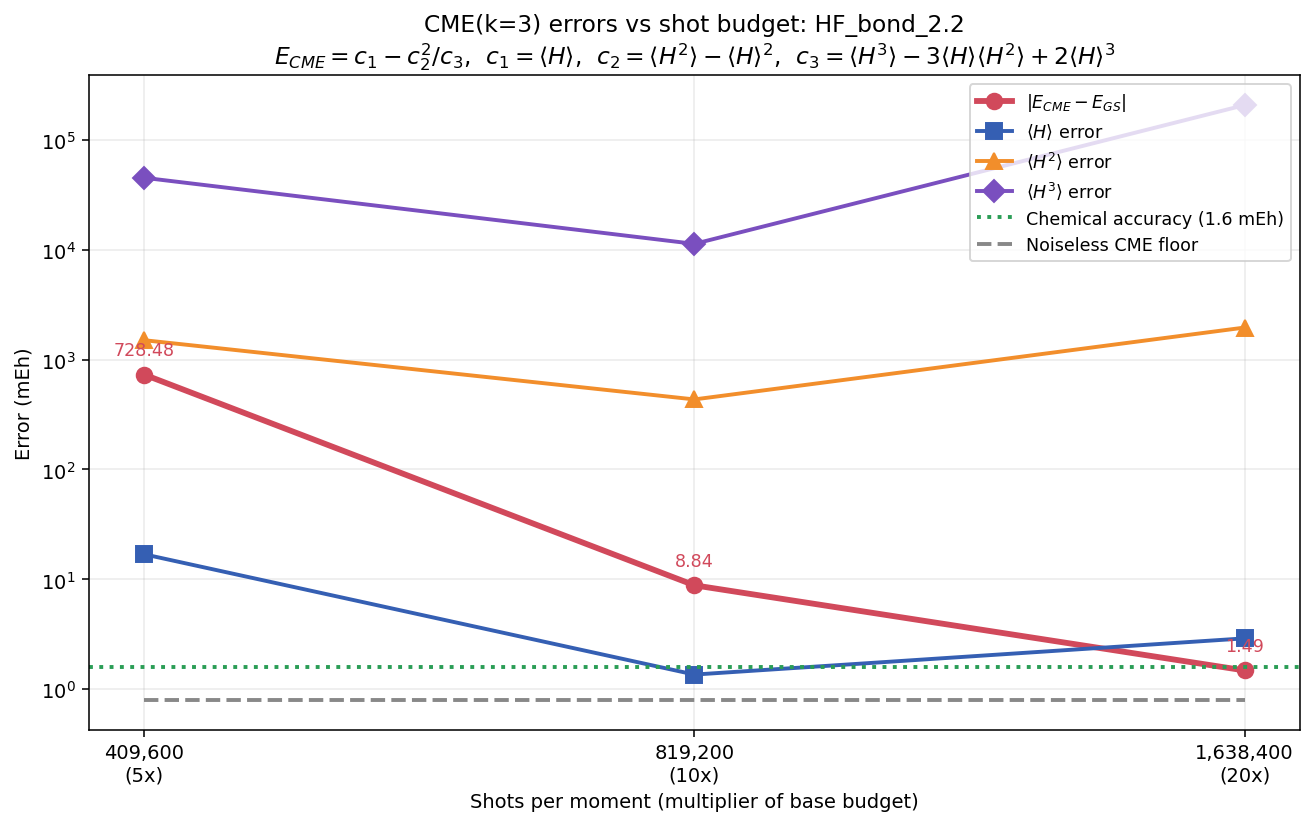

In [5]:
# --- CMX/CME energy error table when sweep data exists ---
import pandas as pd
from IPython.display import display

if not cme_by_multiplier:
    print("No non-empty CMX/CME sweep results found in", RUN_DIR)
else:
    rows = []
    for mult, result in sorted((int(k), v) for k, v in cme_by_multiplier.items()):
        shots = result["shots"]
        moments = result["moments"]
        e_cme = float(result["E_cme_shots"])
        e_cme_noiseless = float(result["E_cme_noiseless"])
        e_gs = float(result["e_gs"])
        err_gs = abs(e_cme - e_gs)
        noiseless_err_gs = abs(e_cme_noiseless - e_gs)
        rows.append(
            {
                "H2/H3 multiplier": mult,
                "H shots": int(shots["H"]),
                "H2 shots": int(shots["H2"]),
                "H3 shots": int(shots["H3"]),
                "<H> noiseless (Eh)": float(moments["H"]["noiseless"]),
                "<H2> noiseless (Eh^2)": float(moments["H2"]["noiseless"]),
                "<H3> noiseless (Eh^3)": float(moments["H3"]["noiseless"]),
                "E_cme noiseless (Eh)": e_cme_noiseless,
                "|noiseless CME - GS| (mEh)": noiseless_err_gs * 1e3,
                "E_cme shots (Eh)": e_cme,
                "E_gs (Eh)": e_gs,
                "|shot CME - GS| (Eh)": err_gs,
                "|shot CME - GS| (mEh)": err_gs * 1e3,
                "shot CME below chem. acc. (1.6 mEh)": err_gs <= 1.6e-3,
            }
        )

    cme_error_table = pd.DataFrame(rows)
    print(f"CMX/CME noiseless references and shot-budget results: {RUN_DIR.name}")
    display(cme_error_table)

    # Single log-log plot: all error curves in mEh.
    shot_counts = cme_error_table["H2 shots"].to_numpy(dtype=float)
    multipliers = cme_error_table["H2/H3 multiplier"].to_numpy(dtype=int)
    shot_tick_labels = [f"{int(s):,}\n({m}x)" for s, m in zip(shot_counts, multipliers)]

    cme_meh = cme_error_table["|shot CME - GS| (mEh)"].to_numpy(dtype=float)
    cme_noiseless_meh = cme_error_table["|noiseless CME - GS| (mEh)"].to_numpy(dtype=float)

    moment_errors_meh = {key: [] for key in ("H", "H2", "H3")}
    for mult, entry in sorted((int(k), v) for k, v in cme_by_multiplier.items()):
        source = entry.get("moment_source", "cdr_rem")
        for key in ("H", "H2", "H3"):
            measured = float(entry["moments"][key][source])
            noiseless = float(entry["moments"][key]["noiseless"])
            moment_errors_meh[key].append(abs(measured - noiseless) * 1e3)

    fig, ax = plt.subplots(figsize=(9.5, 6.0))

    series = [
        (cme_meh, "o", "#d1495b", 3.0, r"$|E_{CME} - E_{GS}|$"),
        (moment_errors_meh["H"], "s", "#355fb3", 2.0, r"$\langle H \rangle$ error"),
        (moment_errors_meh["H2"], "^", "#f28e2b", 2.0, r"$\langle H^2 \rangle$ error"),
        (moment_errors_meh["H3"], "D", "#7a4fbf", 2.0, r"$\langle H^3 \rangle$ error"),
    ]
    for values, marker, color, lw, label in series:
        ax.plot(
            shot_counts,
            values,
            marker=marker,
            markersize=8,
            linewidth=lw,
            color=color,
            label=label,
        )

    ax.axhline(
        1.6,
        color="#2a9d55",
        linestyle=":",
        linewidth=2,
        label="Chemical accuracy (1.6 mEh)",
    )
    ax.plot(
        shot_counts,
        cme_noiseless_meh,
        linestyle="--",
        linewidth=2,
        color="#888888",
        label="Noiseless CME floor",
    )

    for x, meh in zip(shot_counts, cme_meh):
        ax.annotate(
            f"{meh:.2f}",
            (x, meh),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color="#d1495b",
        )

    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(shot_counts)
    ax.set_xticklabels(shot_tick_labels)
    ax.minorticks_off()
    ax.set_xlabel("Shots per moment (multiplier of base budget)")
    ax.set_ylabel("Error (mEh)")
    ax.set_title(
        f"CME(k=3) errors vs shot budget: {RUN_DIR.name}\n"
        r"$E_{CME} = c_1 - c_2^2/c_3$,  "
        r"$c_1 = \langle H \rangle$,  "
        r"$c_2 = \langle H^2 \rangle - \langle H \rangle^2$,  "
        r"$c_3 = \langle H^3 \rangle - 3\langle H \rangle\langle H^2 \rangle + 2\langle H \rangle^3$"
    )
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=9, loc="best")
    fig.tight_layout()
    plt.show()
